In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time 
import pandas as pd
import datetime
import cvxpy as cp
import power_grid_model
from power_grid_model import ComponentType, DatasetType, LoadGenType, PowerGridModel, initialize_array, validation
from power_grid_model import LoadGenType, ComponentType, DatasetType
from power_grid_model import PowerGridModel, CalculationMethod, CalculationType
from power_grid_model import initialize_array

# some basic imports
import warnings

with warnings.catch_warnings(action="ignore", category=DeprecationWarning):
    # suppress warning about pyarrow as future required dependency
    import pandas as pd



In [3]:
price_2023=pd.read_csv("Day-ahead Prices_202301010000-202401010000.csv")
price_2023= price_2023.drop('BZN|NL', axis=1)
price_2023= price_2023.dropna()
price_2023 = price_2023.replace('-', pd.NA)
price_2023= price_2023.dropna()

def prices_day_finder(day,price_2024,Num=1):
    return np.array(price_2024.iloc[day*24:int((day+Num)*24)]["Day-ahead Price [EUR/MWh]"])

day=1
Num=152
price=prices_day_finder(day,price_2023, Num)


In [4]:
#optimzer here
N=24
def capacity_check(Battery_prof,N=24):
    """
    checks wether the battery profile has exceeded the capacity of the battery
        input:
            battery_prof: array[N], battery profile in MW
            capacity    : float   , capacity of battery in MWh
            N           : float   , timessteps per day
        output:
            EFC         : float   , effective full capacity
        
    """ 
    return np.abs((np.max(np.cumsum(Battery_prof))-np.min(np.cumsum(Battery_prof))))*24/N
    
def add_change(bat_prof, step, N=24):
    """
    generates a positive step at a random time moment and a negative step at another random time moment
    input:
        bat_prof: array[N], battery profile to permutate
        step    : float   , stepsize
        N       : int     , amount of timesteps in a day
    output:
        bat_prof_dummy: array[N], batteryprofile with permutation 
    
    """
    
    # Ensure that a and b are distinct indices
    a, b = np.random.choice(N, size=2, replace=False)
    
    bat_prof_dummy = bat_prof.copy()       # Create a copy of the input array
    bat_prof_dummy[a] = bat_prof[a] + step # Add 'step' to the first random index
    bat_prof_dummy[b] = bat_prof[b] - step # Subtract 'step' from the second random index
    return bat_prof_dummy

def random_start(M,N=24,step=1):
    """
    creates a battery profile which has a random start,  M=0 is possible for a flat profile
        input:
            M    : int     , how many random (Markov) steps are done
            N    : int=24  , how many hour in a day 
            step : float=1 , stepsize [MW]
        output:
            bat_prof: array([N]), with M random steps with stepsize step
    """
    
    bat_prof=np.zeros([N])
    for m in range(M):
        bat_prof=add_change(bat_prof,step,N)     # repeatedly add changes M times
        #sleep(0.05)
    return bat_prof   

def eff_mod(profile, efficiency):
    """
    modifies the battery profile to incorperate efficiency by increasing the charge (positive) section
    input:
        profile    : array([24]), battery profile
        efficiency : float      , efficiency form ac/dc-charge-discharge-dc/ac
    output:
        profile_copy: array([24])
    """
    profile_copy = profile.copy()
    profile_copy[profile_copy > 0] = profile_copy[profile_copy > 0] / efficiency
    return profile_copy

def cycles(profile,cap):
    """
    returns the amount of charage/discharge cycles the batter has gone through, i.e. total charge/capacity or total discharge/capacity
    input:
        profile: array(24), battery profile
        cap    : float    , capacity
    return:
        float,  how many cycles the battery has done
    """
  
    profile_copy = profile.copy()
    profile_copy[profile_copy < 0] = profile_copy[profile_copy < 0]
    
    return -np.sum(profile_copy[profile_copy < 0])/cap


def power_check(battery_prof,maxpower,minpower):
    """
    tell wether the battery profile is allowed
    input:
        battery_prof : array(N=24), battery out/input
        maxpower     : array(N=24), maximum allowed power
        minpower     : array(N=24), minimum allowed power
    output           : bool       
    """
    return np.min((battery_prof<maxpower) & (battery_prof>minpower))


def nan_to_last(arr):
    """
    convert nans in a row to the last non nan inpit in that row
    input:
        reveneu :  array, with nans
    output:
        arr     :  array, but nans converted to last non nan input

    """
    arr = arr.T  # Rotate indexes
    for i in range(arr.shape[0]):
        arr[i, :] = np.where(np.isnan(arr[i, :]), np.nanmax(arr[i, :]), arr[i, :])
    return arr.T

def cycles2D(profile, cap):
    """
    Returns the amount of charge/discharge cycles the battery has gone through, i.e. total charge/capacity or total discharge/capacity.
        Input:
        profile: array(24*N), battery profile where each row represents 24 hours of battery data
        cap    : float       , capacity of the battery
    Returns:
        array(N), number of cycles the battery has done for each profile
    """
    
    # Ensure the profile is a 2D array, with each row representing 24-hour battery profile
    profile = np.atleast_2d(profile)
    # Initialize a copy of the profile to modify it without changing the original
    profile_copy = profile.copy()
    # Set values less than 0 (discharge) to remain, others are ignored
    profile_copy[profile_copy >= 0] = 0  # We are only interested in negative values
    # Sum the negative values (discharge) for each row, then divide by capacity
    cycles_per_profile = -np.sum(profile_copy, axis=0) / cap
    return cycles_per_profile


def load_error(bat_prof0,max_power2, min_power2):
    """
    given a battery profile, determine how much error there is between the allowed power and the battery power, makes the limit_array function redundant
    input:
        bat_prof0: array , the battery profile
        max_power: array , the maximum power the battery may deliver
        min_power: array , the minimum power the battery may deliver
    output: 
        the sum amount power the battery profile is outside its allowed margine, interpret it as an error, will be 0 if within the bounds
    
    """
    b=(bat_prof0-max_power2)>0
    b2=(bat_prof0-min_power2)<0
    error=np.abs(np.sum((bat_prof0-max_power2)[b]))
    error2=np.abs(np.sum((bat_prof0-min_power2)[b2]))
    return np.abs(error+error2)


def limit_array(max_power, min_power, battery_max_power, battery_min_power):
    """
    Replace values in the arrays that exceed specified limits with the corresponding boundaries.
    
    Parameters:
    max_power           : array[N], input array to limit
    min_power           : array[N], input array to limit
    battery_max_power   : array[N], maximum allowed value for the arrays
    battery_min_power   : array[N], minimum allowed value for the arrays
   
    Returns:
    max_power : array[N], array with values exceeding battery_max_power replaced by battery_max_power.
    min_power : array[N], array with values exceeding battery_max_power replaced by battery_max_power.
    """
    
    # Error check for invalid range
    if np.any(battery_max_power < battery_min_power):
        raise ValueError("battery_max_power cannot be less than battery_min_power")
    
    # Limit max_power between battery_min_power and battery_max_power
    max_power = np.where(max_power > battery_max_power, battery_max_power, max_power)
    max_power = np.where(max_power < battery_min_power, battery_min_power, max_power)

    # Limit min_power between battery_min_power and battery_max_power
    min_power = np.where(min_power > battery_max_power, battery_max_power, min_power)
    min_power = np.where(min_power < battery_min_power, battery_min_power, min_power)
    
    return max_power, min_power

def text(data,data_bat, eff, text=False):
    j=len(data[0,:])
    money_saved=np.round((data[-1,:]-data[1,:]),0)           
    num_cycles=np.round(cycles2D(data_bat[:,:],capacity),3)
    cap_used=np.max(np.cumsum(eff_mod(data_bat[:,:],1/eff))-np.min(np.cumsum(eff_mod(data_bat[:,:],1/eff))))/(j)
    #cap_used_1=np.max(np.cumsum(eff_mod(data_bat,1/eff))-np.min(np.cumsum(eff_mod(data_bat,1/eff))))
    
    if text==True:
        print("max profit",np.max(money_saved),"EURO")
        print("mean profit",np.mean(money_saved),"EURO")
        print("std profit",np.round(np.std(money_saved),1),"EURO")
        print("relative error",np.round(100*np.std(money_saved)/np.mean(money_saved),3),"%")

        print("mean number of cycles",np.round(np.mean(num_cycles),5))
        print("mean Profit/cycle", np.round((np.mean(money_saved)/np.mean(num_cycles)),0))
        print("mean used capacity used", cap_used)
    return money_saved, num_cycles, cap_used

def graphs(data,data_bat, max_power,min_power, eff, price):
    # battery plot with power limits
    #plt.xlim(0,32)

    for i in range(len(data_bat[0,:])):
        plt.plot(data_bat[:,i])         # plot every charge/discharge profile 
    
    plt.ylabel("Discharge (-) or Charge (+) [MW]")
    plt.xlabel("Time of day [h]")
    plt.title("Battery power");
    #plot the power limits
    plt.plot(max_power,ls=(0,(3,5,1,5)), color="red", label="max power limit")
    plt.plot(min_power,ls=(0,(3,5,1,5)), color="blue", label="min power limit")
    plt.legend(loc="upper right")
    plt.savefig("battery profile with limits.png")
    plt.show()

    # mean and std plot
    mean_axis1 = np.mean(data_bat, axis=1);   # means
    std_axis1 = np.std(data_bat, axis=1) ;    # std

    plt.figure(figsize=(8, 6))
    x = np.arange(24)                         # X-axis for 24 hours
    plt.errorbar(x, mean_axis1, yerr=std_axis1, fmt='--o',color="b", ecolor='b', capsize=5, label='Mean with std')
    plt.fill_between(x, mean_axis1 - std_axis1, mean_axis1 + std_axis1, color='cyan', alpha=.4)
    plt.legend()
    plt.show()

    # revenue plot
    plt.plot(data);
    plt.ylabel("Profit [EUR]")
    plt.xlabel("iteration")
    plt.title("Profit as optimum is reached")
    plt.show()

    # Histogram of cumsum of battery profile and price
    N=24
    x = np.arange(0, N, 1)

    cumsum_bat = np.cumsum(eff_mod(data_bat[:,0],1/eff))
    min_cumsum = np.min(cumsum_bat)
    normalized_cumsum_bat = (cumsum_bat - min_cumsum) / capacity
    y1 = price        # First dataset (line graph)
    y2 = normalized_cumsum_bat  # Second dataset (bar graph)

    # Create the plot
    fig, ax1 = plt.subplots()

    # Plot the first dataset (line graph)

    ax1.bar(x, 100*y2, alpha=0.6, color='#1f77b4', label='Battery charge')
    ax1.set_ylabel('Battery state [%]', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    ax2 = ax1.twinx()
    ax2.plot(x, y1, '#ff7f0e', label='Price [EUR/MWh]')
    ax2.set_xlabel('Time of day')
    ax2.set_ylabel('Price [EUR/MWh]', color='#ff7f0e')
    ax2.tick_params(axis='y', labelcolor='#ff7f0e')
    plt.title('Electricity price and battery state')
    plt.show()
    return

def optimize(price, capacity, eff=1, max_cycles=np.inf,  max_power=np.ones([N])*50, min_power=-np.ones([N])*50, battery_max=50, cycle_cost=0,J=1, I=30000, step_0=1,M=0, half_length=3000, accuracy=0.001, text=False):
    """
        A function that find the optimal battery profile, given these parameters
        input:
            price      : array[N]  , hourly[N] prices of electricity [EURO/MWh]
            capacity   : float     , the capacity of the battery [MWh] 
            eff        : float     , efficiciency of the battery setup (incl. ac/dc converter), 0<eff=<1, 1 by default   
            max_cycles : float     , maximum amount of cycles to permit the battery to make, no limit by default
            max_power  : array[N]  , max power the grid permits, [MW],  50 MW by default
            min_power  : array[N]  , minimum power the grid permits, [MW], -50 MW by default
            battery_max: float     , the maximum power limited by the battery
            cycle_cost : float     , loss of value of the battery caused by degradation per cycle, EURO/cycle
            I          : int       , the max amount of iterations done per attempt of optimisation, 15*N^2 is enough usually 
            step       : float     , stepsize to permutate, [MW],  default 1 MW
            J          : int       , The population size of attempts
            M          : int       , number of markov random steps initially, M=0 by default and gives a flat battery profile
            half_length: int       , the number of iterations no changes had sucesfully been adapted, after which the stepsize halves, 3000 by default, 800+ is suggested
            accuracy   : float     , the smallest stepsize the optimilization will go before it stops, 0.001 MW by default
            text       : boolean   , wether or not the program gives a progres percentage, (usefull for high M, I or accuracy), False by default
        output:
            data     : array[N]  , the profit as function of iteration number
            data_bat : array[N]  , the optimal battery profile
            max_power: array[N]  , same as input but limited by the battery
            min_power: array[N]  , same as input but limited by the battery
    """



    max_power,min_power=limit_array(max_power, min_power, battery_max, -battery_max)
    
    data=np.zeros([I,J])*np.nan  # revenue will be saved in this [Iteration, attempt]   
    data_bat=np.zeros([N,J])     # optmized battery profile      [Hours,battery number]
    

    for j in range(J):

        i=0           # keep track of the iteration
        step=step_0   # copy the stepsize
        I_last=0      # last iteration something changed, used to infer stagnation

        bat_prof0=random_start(M,step=1)                              # random start for battery profile, M=0 -> flat start, the "0" makes it the reference profile
        bat_prof0_real=eff_mod(bat_prof0,eff)                         # battery profile compensated for efficiency
        load_error0=load_error(bat_prof0_real,max_power,min_power)    # sum of deviation from the allowed power
        num_cycles0=cycles(bat_prof0,capacity)                        # counts the amount of cycles (Effective Full Cycles) the battery has gone through
        rev0=-np.sum((price*(bat_prof0_real)))-num_cycles0*cycle_cost #revenue from the battery, degradation subtracted  

        while step>accuracy and i<I:   # while loop stops if the step size has shrunk smaller than the accuracyor the iteration limit is reached

            constraint=False 
            
            if text==True:
                if i%1000==0:              # print progress per 1000 iterations 
                    print ("progress "+str(int(100*(j*I+i)/(J*I)))+"%", end="\r")   
        
            if i-I_last>half_length:   # halves the stepsize every half length if the difference between current index and last index of change is too large
                step=step/2            # half the stepsize
                I_last=i               # remember this index as the last time a change was done
                
            bat_prof_new=add_change(bat_prof0,step,N=24)     # add a change to the battery profile
            bat_prof_new_real=eff_mod(bat_prof_new,eff)      # implement the efficiency 
        
            num_cycles_new=cycles(bat_prof_new,capacity)     # calculate the new amount of cycles
        
            load_error_new=load_error(bat_prof_new_real,max_power,min_power)       # calculate the error from the allowed power of the new battery profile
            rev_new=-np.sum((price*(bat_prof_new_real)))-num_cycles_new*cycle_cost # calculate the revenue of the new battery profile

            if capacity_check(bat_prof0)>capacity_check(bat_prof_new) and capacity_check(bat_prof0)>capacity :  # bring capacity down first
                rev0=rev_new
                bat_prof0=bat_prof_new
                load_error0=load_error_new
                I_last=i 
                constraint=True

            elif load_error0 > 0 and load_error_new<load_error0 and constraint==False:     # bring the battery profile down to between bounds if the start is outside bounds
                rev0=rev_new
                bat_prof0=bat_prof_new
                load_error0=load_error_new
                I_last=i
                constraint=True
            
                                   
            elif rev_new>rev0 and load_error0==0 and load_error_new==0 and constraint==False and cycles(bat_prof_new,capacity)<=max_cycles and capacity_check(bat_prof_new)<capacity:                    # if the load is allowed, rememeber the battery profile with the higher revenue
                rev0=rev_new
                bat_prof0=bat_prof_new
                load_error0=load_error_new
                I_last=i
           
            data[i,j]=rev0                            # save the revenue
            i=i+1                                     # add 1 to the index counter

        
        data_bat[:,j]=eff_mod(bat_prof0,eff)          # save the battery profiles
    
    data=nan_to_last(data)                            # replace the nans with the last non-nan value 
    
    if text==True:
        print("done                ")
    return data,data_bat,max_power,min_power


In [5]:
#load=np.ones([24])*2e6
#load_q=np.ones([24])*0.5e6
#i=1
#battery=-4e6   # negative= energy into the grid

startTime = datetime.datetime.now()

node = initialize_array('input', 'node', 3)
node['id'] = [1, 2,6]    #gives id to node
node['u_rated'] = [10.5e3, 10.5e3,10.5e3]  #give rated potential
# node

c=0.75
# line
line = initialize_array(DatasetType.input, ComponentType.line, 2)
line["id"] = [3,7]   #gives id to lines
line["from_node"] = [1,2]   #coneccted to
line["to_node"] = [2,6]     # ^
line["from_status"] = [1,1]   #start working
line["to_status"] = [1,1]     #end working (incase of malfunction etc.)
line["r1"] = [0.25*c,0.25]  # resistance, impedance and shunt capacitance [0.25,0.25]
line["x1"] = [0.2*c,0.3]    # [0.2,0.3]
line["c1"] = [10e-6*c,10e-6]
line["tan1"] = [0.0,0.0]  # positive-sequence shunt loss factor
line["i_n"] = [2600,50000]  # rated current (A)

# load
sym_load = initialize_array(DatasetType.input, ComponentType.sym_load, 3)
sym_load["id"] = [4,8,9]
sym_load["node"] = [2,6,6]
sym_load["status"] = [1,1,1] 
sym_load["type"] = [LoadGenType.const_power ,LoadGenType.const_power, LoadGenType.const_impedance ]# [LoadGenType.const_current,LoadGenType.const_current] #[LoadGenType.const_power,LoadGenType.const_power]  # # #[LoadGenType.const_power,LoadGenType.const_power]
#power types  # hier
#sym_load["p_specified"] = [battery,load[i]]     #power
#sym_load["q_specified"] = [0,load_q[i]]   #VAR




# source
source = initialize_array(DatasetType.input, ComponentType.source, 1)
source["id"] = [5]
source["node"] = [1]
source["status"] = [1]
source["u_ref"] = [1.0]

# input_data
input_data = {
    ComponentType.node: node,
    ComponentType.line: line,
    ComponentType.sym_load: sym_load,
    ComponentType.source: source,
}

# call constructor
#model = PowerGridModel(input_data, system_frequency=50.0)
#power_grid_model.validation.validate_input_data(input_data) #validation
#result = model.calculate_power_flow(max_iterations=20)

endTime = datetime.datetime.now()
print(endTime - startTime)

0:00:00.000984


In [6]:
load=np.ones([24])*2e7
load_q=np.ones([24])*0.5e6
i=1
battery=-5.5e6   # negative= energy into the grid


sym_load["p_specified"] = [battery,load[i],load[i]]     #power
sym_load["q_specified"] = [0,load_q[i],load_q[i]]   #VAR


# call constructor

model = PowerGridModel(input_data, system_frequency=50.0)
power_grid_model.validation.validate_input_data(input_data) #validation
result = model.calculate_power_flow(max_iterations=20)

print(pd.DataFrame(result[ComponentType.line])["loading"])

0    0.736685
1    0.044753
Name: loading, dtype: float64


In [7]:
def format_powergrid(loads,h,battery):
    """
    takes the loads, hour index and battery power and puts it in a format easily used for the power.grid.model
    input:
        loads   : 2d-array of floats [i,h]    , array of (hourly) loads [W], 1d array is also allowed
        h       : int                         , index of the hour
        battery : float                       , the battery charge or discharge, in [W]
    return:
        returns the battery and loads[h] in an array,   [battery,load1[h],load2[h],load3[h],etc]
    """
    list=[battery]                      # first element is battery 
    if np.shape(loads)==(24,):          # if it is just a one component system, just return it properly
        list=np.append(list,loads[h])  
    else:
        for i in range(len(loads[:,0])):  # if there are more loads than just 
            #print(i)
            list=np.append(list,loads[i,h])
    return list


In [8]:
def find_start(load, load_q,f=0.85, step=2e6, max_i=50, accuracy=1000, N=24 ):
    start=[]
    battery_start=0
    for h in range(N):
        i=0
        battery_n=0
        battery_p=0
        battery_start=0
        overload=True
              
        while i<max_i and overload==True:#
            if i==max_i-1:
                return print("error")
            i=i+1
            battery_p+=step
            sym_load["p_specified"] = format_powergrid(load,h,battery_p)   #power
            sym_load["q_specified"] = format_powergrid(load_q,h,0)       #VAR
    
            # call constructor
            try:
                model = PowerGridModel(input_data, system_frequency=50.0)
                power_grid_model.validation.validate_input_data(input_data) #validation
                result = model.calculate_power_flow(max_iterations=25)
            
                overload=np.sum(pd.DataFrame(result[ComponentType.line])["loading"]>f)>0
            except Exception as e:
                overload = True
                 
            
            if overload==False:
                battery_start=battery_p
                break
           
        
            battery_n-=step

            sym_load["p_specified"] = format_powergrid(load,h,battery_n)   #power
            sym_load["q_specified"] = format_powergrid(load_q,h,0)       #VAR

            try:
                # call constructor
                model = PowerGridModel(input_data, system_frequency=50.0)
                power_grid_model.validation.validate_input_data(input_data) #validation
                result = model.calculate_power_flow(max_iterations=20)
            
                overload=np.sum(pd.DataFrame(result[ComponentType.line])["loading"]>f)>0
            except Exception as e:
                overload = True


            
            if overload==False:
                battery_start=battery_n
                break
        start=np.append(start,battery_start)
    return start


def find_power_limits(f,load,load_q,step_0=1e6,max_i=50,accuracy=1000,battery_start=np.zeros(24)):  # add load[h] & load_q[h] later

    overload=False
    max_power=[]
    min_power=[]
    for h in range(24):

        step=step_0
        overload=False
        i=0
        battery=battery_start[h]
    
        
        while i<max_i and step>accuracy:# and overload==False:
            i=i+1
            
            battery+=step
            sym_load["p_specified"] = format_powergrid(load,h,battery)   #power
            sym_load["q_specified"] = format_powergrid(load_q,h,0)       #VAR
            
            try:
                # call constructor
                model = PowerGridModel(input_data, system_frequency=50.0)
                power_grid_model.validation.validate_input_data(input_data) #validation
                result = model.calculate_power_flow(max_iterations=20)
            
                overload=np.sum(pd.DataFrame(result[ComponentType.line])["loading"]>f)>0

            except Exception as e:
                overload = True
                
            if overload==True:
                battery-=step
                step=step/2
                overload=False
        max_power=np.append(max_power,battery/1e6)

        battery=battery_start[h]
        i=0
        step=step_0
        overload=False
    
        
        while i<max_i and step>accuracy:# and overload==False:
            i=i+1
            
            battery-=step
            sym_load["p_specified"] = format_powergrid(load,h,battery)   #power
            sym_load["q_specified"] = format_powergrid(load_q,h,0)       #VAR

            try:
                # call constructor
                model = PowerGridModel(input_data, system_frequency=50.0)
                power_grid_model.validation.validate_input_data(input_data) #validation
                result = model.calculate_power_flow(max_iterations=20)
            
                overload=np.sum(pd.DataFrame(result[ComponentType.line])["loading"]>f)>0
            except Exception as e:
                overload = True
            
            if overload==True:
                battery+=step
                step=step/2
                overload=0
        min_power=np.append(min_power,battery/1e6)
        
    return  max_power, min_power

In [9]:
demand=np.array([ 181653.33891111, 143011.66785315,  144027.20282751, 127336.10907843,  134168.67394214,  132823.51908577, 125928.99991089, 47912.71965276,  -91807.23094239,      -194289.40861056, -288161.77556796, -311369.02415312, -288252.64297038, -286188.22396203, -208085.58141745, -113736.74423121, 34793.42733598,  187892.43437513,  272930.83007863,  299841.36843624,  337104.22479038,  325258.22942958,  271786.64543865,  224437.79140606])
mag=50e6*.95
load_p=demand/np.max(demand)*mag*.3
load_c=demand/np.max(demand)*mag*.7
load=np.vstack([load_p,load_c])
#load

f=1

load_q=load*0.05

start=find_start(load, load_q,f=f)
#print(start)
#plt.plot(start/1e6)
#plt.ylim(-55,55)
max_power,min_power=find_power_limits(f,load,load_q,step_0=1e6,max_i=50,accuracy=1000, battery_start=start) 


In [10]:
price=prices_day_finder(day,price_2023, 1)

data,data_bat,max_power,min_power=optimize(price, capacity=200, eff=1,  max_power=max_power, min_power=min_power, battery_max=50, cycle_cost=6000,J=1, I=5000, step_0=1,M=0, half_length=3000, accuracy=0.001, text=1)
#plt.plot(data)

done                


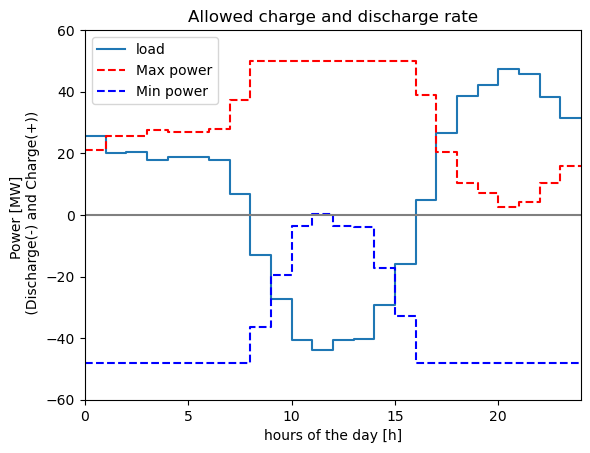

In [11]:
load2=(load_p+load_c)/1e6
load3=np.append(load2[0],load2)
plt.step(np.arange(25),load3, label="load",where="pre")
plt.ylim(-60,60)

#plt.step(np.arange(len(data_bat)+1),np.append(data_bat,data_bat[-1]),where="post",  linewidth=3, label="Battery")
plt.step(np.arange(len(max_power)+1),np.append(max_power,max_power[-1]), ls="--",color="red", where="post", label="Max power")
plt.step(np.arange(len(min_power)+1),np.append(min_power,min_power[-1]), ls="--",color="Blue", where="post", label="Min power")

plt.hlines(0,0,24,color="grey")
plt.xlabel("hours of the day [h]")
plt.ylabel("Power [MW] \n (Discharge(-) and Charge(+))")
plt.title("Allowed charge and discharge rate")
plt.xlim(0,24)
plt.legend();
#plt.savefig("maximum-minimum allowed charge3.png")


profit [12614.06]


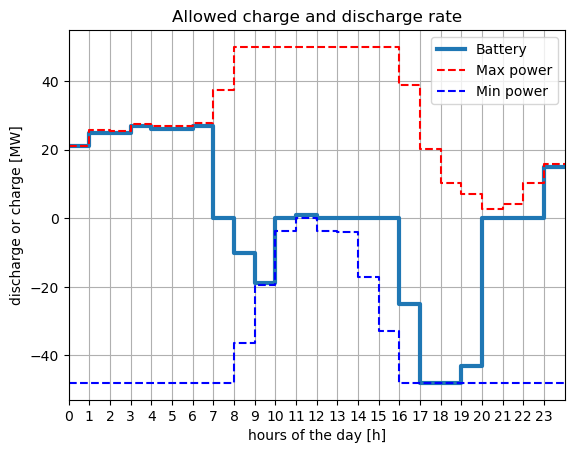

In [12]:
plt.step(np.arange(len(data_bat)+1),np.append(data_bat,data_bat[-1]),where="post",  linewidth=3, label="Battery")
plt.step(np.arange(len(max_power)+1),np.append(max_power,max_power[-1]), ls="--",color="red", where="post", label="Max power")
plt.step(np.arange(len(min_power)+1),np.append(min_power,min_power[-1]), ls="--",color="Blue", where="post", label="Min power")
plt.xlabel("hours of the day [h]")
plt.ylabel("discharge or charge [MW]")
plt.title("Allowed charge and discharge rate")
plt.xlim(0,24)
plt.xticks(np.arange(24));
plt.grid()
plt.legend()
print("profit",data[-1])
plt.show()

profit [6587.57019118]


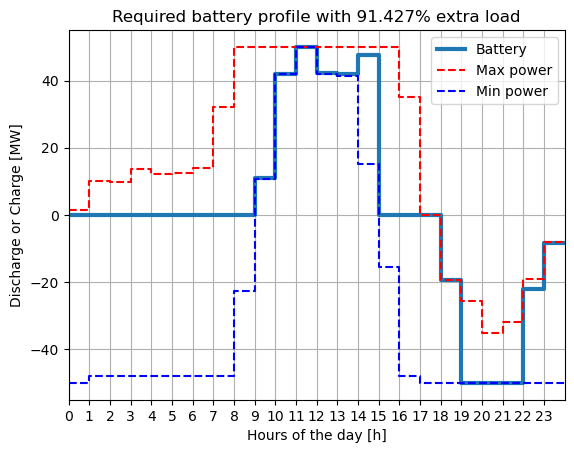

In [14]:
demand=np.array([ 181653.33891111,  143011.66785315,  144027.20282751,        127336.10907843,  134168.67394214,  132823.51908577,        125928.99991089,   47912.71965276,  -91807.23094239,      -194289.40861056, -288161.77556796, -311369.02415312,       -288252.64297038, -286188.22396203, -208085.58141745,       -113736.74423121,   34793.42733598,  187892.43437513,        272930.83007863,  299841.36843624,  337104.22479038,        325258.22942958,  271786.64543865,  224437.79140606])
mag=50e6*.95
load_p=demand/np.max(demand)*mag*.3
load_c=demand/np.max(demand)*mag*.7
load=np.vstack([load_p,load_c])
demand=load

price=prices_day_finder(152,price_2023, 90)
price[::24]
mean_price=[]
for i in range(24):
    mean_price=np.append(mean_price,np.mean(price[i::24]))
price=mean_price

eff=0.85
depcost=6000
f=1
i=2
index=0
i_old=i
step=0.5
while index<50:
    index+=1
    load=demand*i
    load_q=load*0.05
    print(str(np.round((i-1)*100,3))+"%", end="\r")
    start=find_start(load, load_q,f=f)
    #print("start found")
    max_power,min_power=find_power_limits(f,load,load_q,step_0=1e6,max_i=50,accuracy=1000, battery_start=start)
    #print("max and min found")
    data,data_bat,max_power,min_power=optimize(price, capacity=200, eff=eff,  max_power=max_power, min_power=min_power, battery_max=50, cycle_cost=depcost,J=1, I=20000, step_0=1,M=0, half_length=1200, accuracy=0.001, text=0)
        
    if  np.max(max_power==min_power)==False and np.max(data_bat[:,0]<=max_power) and np.max(data_bat[:,0]>=min_power):
        if step<0.001:
            break
        i_old = i
        i+=step*2/3
        step=step/3
        
    else:
        i-=step # reduce i 
        #print("max power = min power")

plt.step(np.arange(len(data_bat)+1),np.append(data_bat,data_bat[-1]),where="post",  linewidth=3, label="Battery")
plt.step(np.arange(len(max_power)+1),np.append(max_power,max_power[-1]), ls="--",color="red", where="post", label="Max power")
plt.step(np.arange(len(min_power)+1),np.append(min_power,min_power[-1]), ls="--",color="Blue", where="post", label="Min power")
plt.xlabel("Hours of the day [h]")
plt.ylabel("Discharge or Charge [MW]")
plt.title("Allowed charge and discharge rate")
plt.xlim(0,24)
plt.xticks(np.arange(24));
plt.grid()
plt.legend()
print("profit",data[-1])
plt.title("Required battery profile with "+str(np.round((i-1)*100,3))+"% extra load")
#plt.savefig(str(i)+"bp.png")
plt.show()
        

In [20]:
demand=np.array([ 181653.33891111,  143011.66785315,  144027.20282751,        127336.10907843,  134168.67394214,  132823.51908577,        125928.99991089,   47912.71965276,  -91807.23094239,      -194289.40861056, -288161.77556796, -311369.02415312,       -288252.64297038, -286188.22396203, -208085.58141745,       -113736.74423121,   34793.42733598,  187892.43437513,        272930.83007863,  299841.36843624,  337104.22479038,        325258.22942958,  271786.64543865,  224437.79140606])
mag=50e6*.95
load_p=demand/np.max(demand)*mag*.3
load_c=demand/np.max(demand)*mag*.7
load=np.vstack([load_p,load_c])
demand=load

price=prices_day_finder(152,price_2023, 90)
price[::24]
mean_price=[]
for i in range(24):
    mean_price=np.append(mean_price,np.mean(price[i::24]))
price=mean_price

eff=0.85
depcost=6000
f=1



def find_max_load(price,i=3,step=.5,bat_power=50,bat_cap=200, plot=False):
    i=2
    index=0
    i_old=i
    step=0.5
    
    
    extra_load=[]
    profit=[]
    
    while index<50:
        index+=1
        load=demand*i
        load_q=load*0.05
        print(str(np.round((i-1)*100,3))+"%", end="\r")
        start=find_start(load, load_q,f=f)
        #print("start found")
        max_power,min_power=find_power_limits(f,load,load_q,step_0=1e6,max_i=50,accuracy=1000, battery_start=start)
        #print("max and min found")
        data,data_bat,max_power,min_power=optimize(price, capacity=bat_cap, eff=eff,  max_power=max_power, min_power=min_power, battery_max=bat_power, cycle_cost=depcost,J=1, I=20000, step_0=1,M=0, half_length=1200, accuracy=0.001, text=0)
            
        if  np.max(max_power==min_power)==False and np.max(data_bat[:,0]<=max_power) and np.max(data_bat[:,0]>=min_power):
            if step<0.001:
                break
            i_old = i
            i+=step*2/3
            step=step/3
            
        else:
            i-=step # reduce i 
            #print("max power = min power")

    if plot==True:    
        plt.step(np.arange(len(data_bat)+1),np.append(data_bat,data_bat[-1]),where="post",  linewidth=3, label="Battery")
        plt.step(np.arange(len(max_power)+1),np.append(max_power,max_power[-1]), ls="--",color="red", where="post", label="Max power")
        plt.step(np.arange(len(min_power)+1),np.append(min_power,min_power[-1]), ls="--",color="Blue", where="post", label="Min power")
        plt.xlabel("Hours of the day [h]")
        plt.ylabel("Discharge or Charge [MW]")
        plt.title("Allowed charge and discharge rate")
        plt.xlim(0,24)
        plt.xticks(np.arange(24));
        plt.grid()
        plt.legend()
        print("profit",data[-1])
        plt.title("Required battery profile with "+str(np.round((i-1)*100,3))+"% extra load")
        #plt.savefig(str(i)+"bp.png")
        plt.show()
            

profit [6580.17469444]


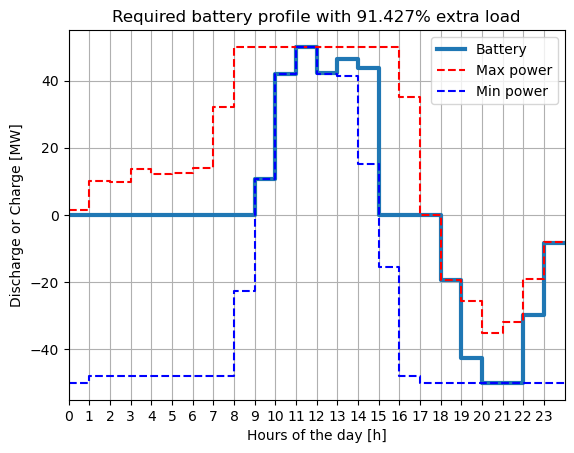

In [21]:
find_max_load(i=3,bat_power=50,bat_cap=200, price=price)
